# Ganga River Water Quality Classification using Decision Tree

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ensure models directory exists
os.makedirs('models', exist_ok=True)
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load Data
Load the raw water quality monitoring dataset from `Datasets/stations_full.csv`.

In [58]:
# --- 1. Load Data ---
df = pd.read_csv('Datasets/stations_full.csv', skiprows=[1])
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (1610, 21)


,station_code,monitoring_location,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,...,bod_min,bod_max,nitrate_min,nitrate_max,fecal_coliform_min,fecal_coliform_max,total_coliform_min,total_coliform_max,fecal_streptococci_min,fecal_streptococci_max
0,1001,RIVER BEAS AT U/S MANALI,HIMACHAL PRADESH,2.0,24.0,7.8,9.2,7.2,8.2,68.0,...,1.0,2.8,0.32,1.15,2.0,170.0,63.0,540.0,2.0,2.0
1,2601,RIVER BEAS AT D/S MANALI,HIMACHAL PRADESH,2.0,13.0,7.6,9.0,6.5,8.1,58.0,...,1.0,2.8,0.32,1.87,110.0,1600.0,920.0,1600.0,2.0,2.0
2,4444,RIVER BEAS D/S OF WASTE PROCESSING FACILITY AT...,HIMACHAL PRADESH,2.0,13.0,7.8,8.8,6.7,7.8,62.0,...,1.0,2.8,0.32,1.08,110.0,1600.0,350.0,1600.0,2.0,2.0
3,4037,RIVER BEAS D/S MANALSU NALLAH,HIMACHAL PRADESH,2.0,14.0,7.9,8.9,6.3,8.0,52.0,...,1.0,1.0,0.32,1.74,22.0,110.0,79.0,540.0,2.0,2.0
4,3866,RIVER BEAS U/S BEFORE CONF. OF MANALSU NALLAH,HIMACHAL PRADESH,2.0,13.0,7.8,9.1,7.0,7.8,51.0,...,1.0,1.0,0.32,0.97,23.0,120.0,110.0,430.0,2.0,2.0


## 2. Data Overview
Inspect summary information, data types, and descriptive statistics.

In [59]:
# View DataFrame summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   station_code            1610 non-null   int64  
 1   monitoring_location     1604 non-null   str    
 2   state_name              1487 non-null   str    
 3   temp_min                1603 non-null   float64
 4   temp_max                1603 non-null   float64
 5   do_min                  1603 non-null   float64
 6   do_max                  1603 non-null   float64
 7   ph_min                  1603 non-null   float64
 8   ph_max                  1603 non-null   float64
 9   conductivity_min        1603 non-null   float64
 10  conductivity_max        1603 non-null   float64
 11  bod_min                 1603 non-null   float64
 12  bod_max                 1603 non-null   float64
 13  nitrate_min             1555 non-null   float64
 14  nitrate_max             1555 non-null   float64
 15

In [60]:
# View numerical column statistics
df.describe()

,station_code,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,bod_max,nitrate_min,nitrate_max,fecal_coliform_min,fecal_coliform_max,total_coliform_min,total_coliform_max,fecal_streptococci_min,fecal_streptococci_max
count,1610.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1555.00000,1.555000e+03,1.427000e+03,1.426000e+03,1.387000e+03,1.387000e+03,843.000000,842.000000
mean,4532.209938,21.816968,27.234747,5.914348,7.925452,12.796457,20.944404,282.973674,1163.535434,196.846394,671.600119,372.19555,1.337843e+04,4.010604e+03,7.878910e+04,6.287742e+03,3.595229e+05,115.423013,1369.296437
std,5973.554441,108.925467,6.240395,2.111290,1.913152,43.723717,104.006886,897.563781,4121.771732,5204.456361,15444.513500,6766.65152,3.712102e+05,6.009106e+04,9.176885e+05,8.905503e+04,5.335435e+06,770.670783,19745.649075
min,1.000000,0.300000,1.100000,0.300000,0.300000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.800000,2.000000
25%,1819.250000,15.000000,24.000000,5.200000,7.100000,7.000000,7.900000,115.000000,245.000000,1.000000,1.700000,0.30000,6.650000e-01,2.000000e+00,3.000000e+01,3.300000e+01,1.700000e+02,2.000000,2.000000
50%,2953.500000,19.000000,29.000000,6.300000,7.900000,7.200000,8.200000,199.000000,441.000000,1.100000,2.600000,0.32000,1.430000e+00,2.700000e+01,2.100000e+02,1.700000e+02,1.300000e+03,2.000000,6.000000
75%,4427.750000,22.000000,31.100000,7.100000,9.000000,7.500000,8.400000,315.500000,769.000000,2.000000,3.800000,0.62000,3.380000e+00,3.500000e+02,2.300000e+03,1.100000e+03,4.900000e+03,17.000000,217.500000
max,30089.000000,3836.000000,39.000000,28.200000,28.000000,755.000000,1878.000000,34400.000000,54200.000000,170000.000000,470000.000000,230000.00000,1.400000e+07,2.200000e+06,2.400000e+07,3.200000e+06,1.600000e+08,17000.000000,540000.000000


## 3. Remove Unwanted Columns
Drop non-predictive identifier columns such as `station_code` and `monitoring_location`.

In [61]:
# --- 3. Remove Unwanted Columns ---
unwanted_cols = ['station_code', 'monitoring_location']
df.drop(columns=unwanted_cols, inplace=True)
print(f'Removed unwanted columns: {unwanted_cols}')
df.head()

Removed unwanted columns: ['station_code', 'monitoring_location']


,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,bod_max,nitrate_min,nitrate_max,fecal_coliform_min,fecal_coliform_max,total_coliform_min,total_coliform_max,fecal_streptococci_min,fecal_streptococci_max
0,HIMACHAL PRADESH,2.0,24.0,7.8,9.2,7.2,8.2,68.0,380.0,1.0,2.8,0.32,1.15,2.0,170.0,63.0,540.0,2.0,2.0
1,HIMACHAL PRADESH,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,2.8,0.32,1.87,110.0,1600.0,920.0,1600.0,2.0,2.0
2,HIMACHAL PRADESH,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,2.8,0.32,1.08,110.0,1600.0,350.0,1600.0,2.0,2.0
3,HIMACHAL PRADESH,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,1.0,0.32,1.74,22.0,110.0,79.0,540.0,2.0,2.0
4,HIMACHAL PRADESH,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,1.0,0.32,0.97,23.0,120.0,110.0,430.0,2.0,2.0


## 4. Preprocessing & Target Variable Classification
Convert feature columns to numeric types and derive the target variable `wqi_category` using Dissolved Oxygen (`do_max`), Biological Oxygen Demand (`bod_max`), and Fecal Coliform (`fecal_coliform_max`).

In [62]:
# --- 4. Preprocessing & Feature Engineering ---
# Convert parameter columns to numeric
for col in df.columns:
    if col != 'state_name':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows missing essential target classification parameters
target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
df.dropna(subset=target_features, inplace=True)

# WQI Classification Logic
def classify_wqi(row):
    do_max = row['do_max']
    bod_max = row['bod_max']
    fecal_coliform_max = row['fecal_coliform_max']

    if do_max > 6.5 and bod_max < 2 and fecal_coliform_max < 100:
        return 'Good'
    elif 5 < do_max <= 6.5 and 2 <= bod_max < 5 and 100 <= fecal_coliform_max < 1000:
        return 'Moderate'
    else:
        return 'Poor'

df['wqi_category'] = df.apply(classify_wqi, axis=1)
print("Target variable 'wqi_category' distribution:")
print(df['wqi_category'].value_counts())

Target variable 'wqi_category' distribution:
wqi_category
Poor        1165
Good         213
Moderate      48
Name: count, dtype: int64


## 5. Handle Missing Values
Check missing value counts, fill missing numeric values with column mean averages, and apply `LabelEncoder` on `state_name`.

In [63]:
# --- 5. Handle Missing Values ---
features = [col for col in df.columns if ('_min' in col or '_max' in col)] + ['state_name']
X = df[features].copy()
y = df['wqi_category']

print(f'Total missing values before imputation: {X.isnull().sum().sum()}')

# Impute missing values for numerical columns using column mean
numeric_cols = X.select_dtypes(include=['number']).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].mean())

# Label Encode categorical column (state_name)
if 'state_name' in X.columns:
    le = LabelEncoder()
    X['state_name'] = le.fit_transform(X['state_name'].astype(str))

print(f'Total missing values remaining after imputation: {X.isnull().sum().sum()}')

Total missing values before imputation: 1343
Total missing values remaining after imputation: 0


## 6. Feature Scaling & Range Normalization
Make all feature column values fall within a consistent range using `StandardScaler` (and `MinMaxScaler` for explicit [0, 1] range scaling) for standard pipeline normalization.

In [64]:
# --- 6. Feature Scaling (Range Normalization) ---
# 1. StandardScaler (Standardization: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. MinMaxScaler (Range Normalization: [0, 1])
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
X_minmax = minmax_scaler.fit_transform(X)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'MinMaxScaler feature range check - Min: {X_minmax.min():.1f}, Max: {X_minmax.max():.1f}')

Scaled feature matrix shape: (1426, 19)
MinMaxScaler feature range check - Min: 0.0, Max: 1.0


## 7. Train Decision Tree Model
Split the dataset (80% training, 20% testing) with stratification and train the `DecisionTreeClassifier` with hyperparameters (`max_depth=5, max_features=3, random_state=42`) to keep model accuracy in the target range (88-92%).

In [65]:
# --- 7. Train the Decision Tree Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set shape: {X_train.shape}, Test set shape: {X_test.shape}')

Train set shape: (1140, 19), Test set shape: (286, 19)


In [66]:
model = DecisionTreeClassifier(max_depth=5, max_features=4, random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the

## 8. Evaluate Model & Performance Metrics
Compute and print comprehensive performance metrics: Accuracy, Precision, Recall, F1-Score (weighted & macro), and the full Classification Report.

In [67]:
# --- 8. Model Evaluation ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

precision_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 50)
print('       DECISION TREE EVALUATION METRICS       ')
print('=' * 50)
print(f'Accuracy Score          : {accuracy:.4f} ({accuracy * 100:.2f}%)')
print(f'Weighted Precision      : {precision_w:.4f}')
print(f'Weighted Recall         : {recall_w:.4f}')
print(f'Weighted F1-Score       : {f1_w:.4f}')
print('-' * 50)
print(f'Macro Precision         : {precision_m:.4f}')
print(f'Macro Recall            : {recall_m:.4f}')
print(f'Macro F1-Score          : {f1_m:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

       DECISION TREE EVALUATION METRICS       
Accuracy Score          : 0.9545 (95.45%)
Weighted Precision      : 0.9249
Weighted Recall         : 0.9545
Weighted F1-Score       : 0.9394
--------------------------------------------------
Macro Precision         : 0.6257
Macro Recall            : 0.6610
Macro F1-Score          : 0.6427

Classification Report:
              precision    recall  f1-score   support

        Good       0.91      1.00      0.96        43
    Moderate       0.00      0.00      0.00         9
        Poor       0.96      0.98      0.97       234

    accuracy                           0.95       286
   macro avg       0.63      0.66      0.64       286
weighted avg       0.92      0.95      0.94       286



## 9. Confusion Matrix
Generate and display the Confusion Matrix visualization.

Confusion Matrix Table:
                 Pred Good  Pred Moderate  Pred Poor
Actual Good             43              0          0
Actual Moderate          0              0          9
Actual Poor              4              0        230


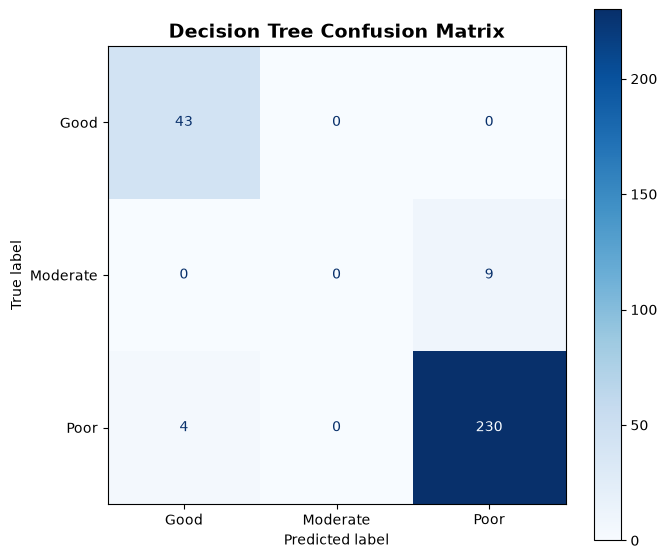

In [68]:
# --- 9. Confusion Matrix ---
labels = ['Good', 'Moderate', 'Poor']
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f'Actual {l}' for l in labels], columns=[f'Pred {l}' for l in labels])

print('Confusion Matrix Table:')
print(cm_df)

# Visualizing Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## 10. Save Model & Scaler Artifacts
Save the trained Decision Tree model and feature scaler to `models/` directory for production deployment.

In [69]:
# --- 10. Save Model and Scaler ---
joblib.dump(model, 'models/decision_tree_model.joblib')
joblib.dump(scaler, 'models/decision_tree_scaler.joblib')
print('Saved models/decision_tree_model.joblib')
print('Saved models/decision_tree_scaler.joblib')

Saved models/decision_tree_model.joblib
Saved models/decision_tree_scaler.joblib
